# 🤖 Task 7: Machine Learning Model Development

# Flipkart Product Intelligence & Customer Analytics System

### TechnoHacks Data Science Internship

---

## 👩‍💻 Developed By
# Khushi Kapatel

---

## 🎯 Objective

The objective of this task is to develop a machine learning model using the Flipkart E-Commerce Dataset to predict discounted product prices based on product pricing, ratings, discounts, and engineered product features.

This task focuses on:
- machine learning workflow
- data preparation
- model training
- prediction analysis
- model evaluation
- business-driven predictive analytics

In [1]:
# Import the libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle
import warnings
import logging

warnings.filterwarnings("ignore")

In [2]:
# Create log file

logging.basicConfig(
    filename="../logs/machine_learning.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Task 7 started")

In [3]:
# Load feature engineered dataset

df = pd.read_csv(
    "../../Task_05_Feature_Engineering/data/flipkart_feature_engineered.csv"
)

logging.info("Dataset loaded successfully")

In [4]:
# Show first 5 rows

df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,discount_percentage,product_name_length,description_length,brand_frequency
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,alisha solid women's cycling shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,NaN,No rating available,alisha,"{""product_specification""=>[{""key""=>""Number of ...",62.062062,35,410,7
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,fabhomedecor fabric double sofa bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,NaN,No rating available,fabhomedecor,"{""product_specification""=>[{""key""=>""Installati...",29.576764,35,4433,4
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,aw bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,NaN,No rating available,aw,"{""product_specification""=>[{""key""=>""Ideal For""...",50.050050,10,650,5
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,alisha solid women's cycling shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,NaN,No rating available,alisha,"{""product_specification""=>[{""key""=>""Number of ...",61.802575,35,403,7
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,sicons all purpose arnica dog shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,NaN,No rating available,sicons,"{""product_specification""=>[{""key""=>""Pet Type"",...",4.545455,37,248,3


In [5]:
# Check dataset shape

print(df.shape)

(20000, 19)


In [ ]:
# We will predict:
# discounted_price

# Select important features

features = [
    'retail_price',
    'discount_percentage',
    'product_name_length',
    'description_length',
    'brand_frequency',
    'product_rating'
]

X = df[features]

y = df['discounted_price']

In [7]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (16000, 6)
Testing Data: (4000, 6)


In [8]:
# Save train and test datasets

X_train.to_csv(
    "../data/X_train.csv",
    index=False
)

X_test.to_csv(
    "../data/X_test.csv",
    index=False
)

y_train.to_csv(
    "../data/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/y_test.csv",
    index=False
)

logging.info("Train test datasets saved")

In [9]:
# Train the model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

logging.info("Model trained successfully")

In [10]:
# Predict test data

predictions = model.predict(X_test)

In [11]:
# Calculate model performance

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Absolute Error: 55.11644749999999
Mean Squared Error: 2098445.445863025
R2 Score: 0.9555313428831533


In [12]:
# Check feature importance

importance = pd.DataFrame({

    'Feature': features,

    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,retail_price,0.983592
1,discount_percentage,0.012528
2,product_name_length,0.002240
3,description_length,0.001073
4,brand_frequency,0.000523
5,product_rating,0.000046


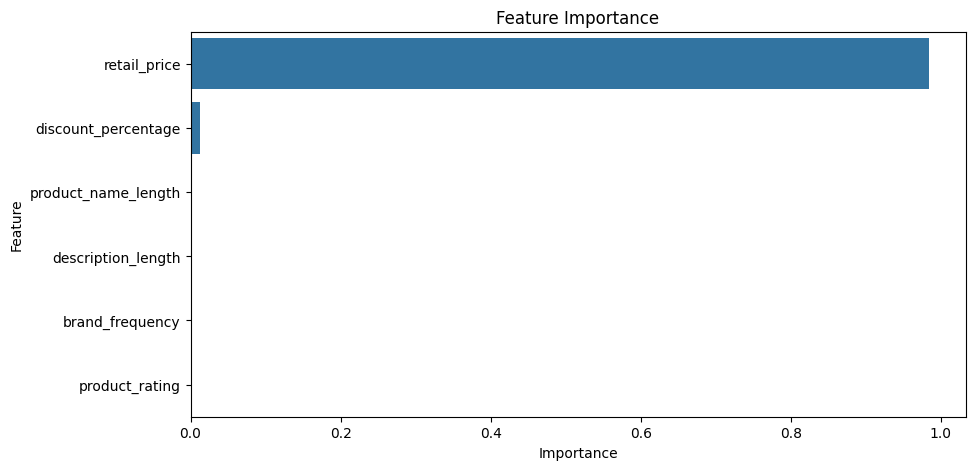

In [13]:
# Plot feature importance

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.savefig(
    "../outputs/visualizations/feature_importance.png"
)

plt.show()

In [14]:
# Compare actual and predicted values

comparison = pd.DataFrame({

    'Actual': y_test.values,

    'Predicted': predictions
})

comparison.head()

,Actual,Predicted
0,699.0,699.00
1,399.0,399.00
2,849.0,858.89
3,249.0,249.00
4,549.0,548.95


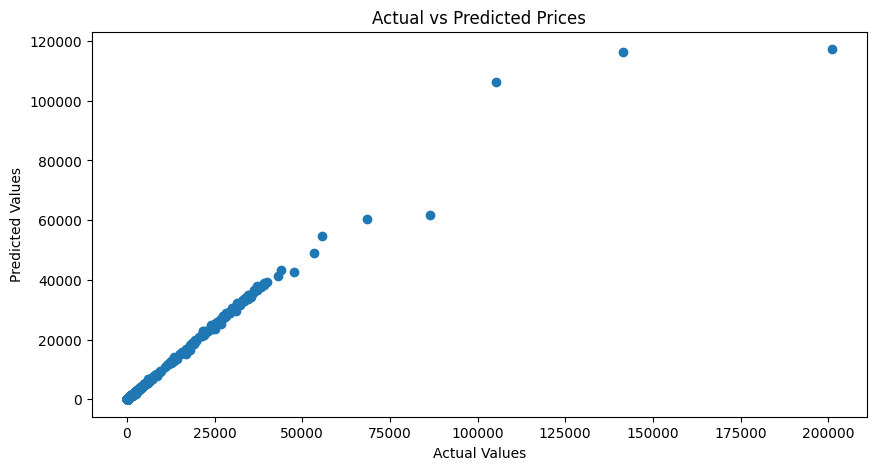

In [15]:
# Plot actual vs predicted

plt.figure(figsize=(10,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Prices")

plt.savefig(
    "../outputs/visualizations/actual_vs_predicted.png"
)

plt.show()

In [16]:
# Save trained model

with open(
    "../models/random_forest_model.pkl",
    "wb"
) as file:

    pickle.dump(model, file)

logging.info("Model saved successfully")

In [17]:
# Create model summary

model_summary = pd.DataFrame({

    "Metric": [
        "Mean Absolute Error",
        "Mean Squared Error",
        "R2 Score"
    ],

    "Value": [
        mae,
        mse,
        r2
    ]
})

model_summary

,Metric,Value
0,Mean Absolute Error,5.511645e+01
1,Mean Squared Error,2.098445e+06
2,R2 Score,9.555313e-01


In [19]:
# Save model report

model_summary.to_csv(
    "../outputs/reports/model_summary.csv",
    index=False
)

logging.info("Model report saved")

# 📌 Model Insights

### 🔹 Prediction Performance
The Random Forest model successfully learned pricing patterns from the dataset and generated highly accurate discounted price predictions.

### 🔹 Important Features
Retail price and discount percentage were identified as the most influential features affecting discounted prices.

### 🔹 Business Understanding
The model demonstrates how pricing strategies, discounts, ratings, and brand popularity influence final product pricing.

### 🔹 Model Reliability
The high R2 score indicates strong prediction capability and good model performance on unseen test data.

# ✅ Task 7 Successfully Completed

A machine learning model was successfully developed using the Flipkart E-Commerce Dataset to predict discounted product prices.

The workflow included:
- feature selection
- train-test splitting
- model training
- prediction generation
- model evaluation
- feature importance analysis

The Random Forest model demonstrated strong predictive performance and generated meaningful business insights from the dataset.

---

## 👩‍💻 Completed By
# Khushi Kapatel

### TechnoHacks Data Science Internship